In [ ]:
# === CONFIGURATION — edit paths here ===
SCHEDULER_DIR = '/glade/derecho/scratch/schreck/CREDIT_runs/ensemble/scheduler'
# Archive (read-only): all outputs are backed up to:
#   /glade/campaign/cisl/aiml/credit/models/sdl_camulator/era5_ensemble_2022


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from datetime import datetime, timedelta
from multiprocessing import Pool
import argparse
import logging
import yaml
import glob
import warnings
import os
import sys
from credit.forecast import load_forecasts
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

### Plot some ensemble members at different lead times

Loading 2d lead: netcdf_pressure_interp/2022-01-16T00Z/pred_2022-01-16T00Z_048.nc
  Selected members for 2d: [11, 78, 93, 36, 43]
Loading 4d lead: netcdf_pressure_interp/2022-01-14T00Z/pred_2022-01-14T00Z_096.nc
  Selected members for 4d: [82, 29, 64, 88, 14]
Loading 6d lead: netcdf_pressure_interp/2022-01-12T00Z/pred_2022-01-12T00Z_144.nc
  Selected members for 6d: [8, 82, 74, 81, 35]
Loading 8d lead: netcdf_pressure_interp/2022-01-10T00Z/pred_2022-01-10T00Z_192.nc
  Selected members for 8d: [9, 39, 91, 94, 98]
Loading 10d lead: netcdf_pressure_interp/2022-01-08T00Z/pred_2022-01-08T00Z_240.nc
  Selected members for 10d: [81, 69, 16, 78, 31]

Loaded data for 5 initialization times


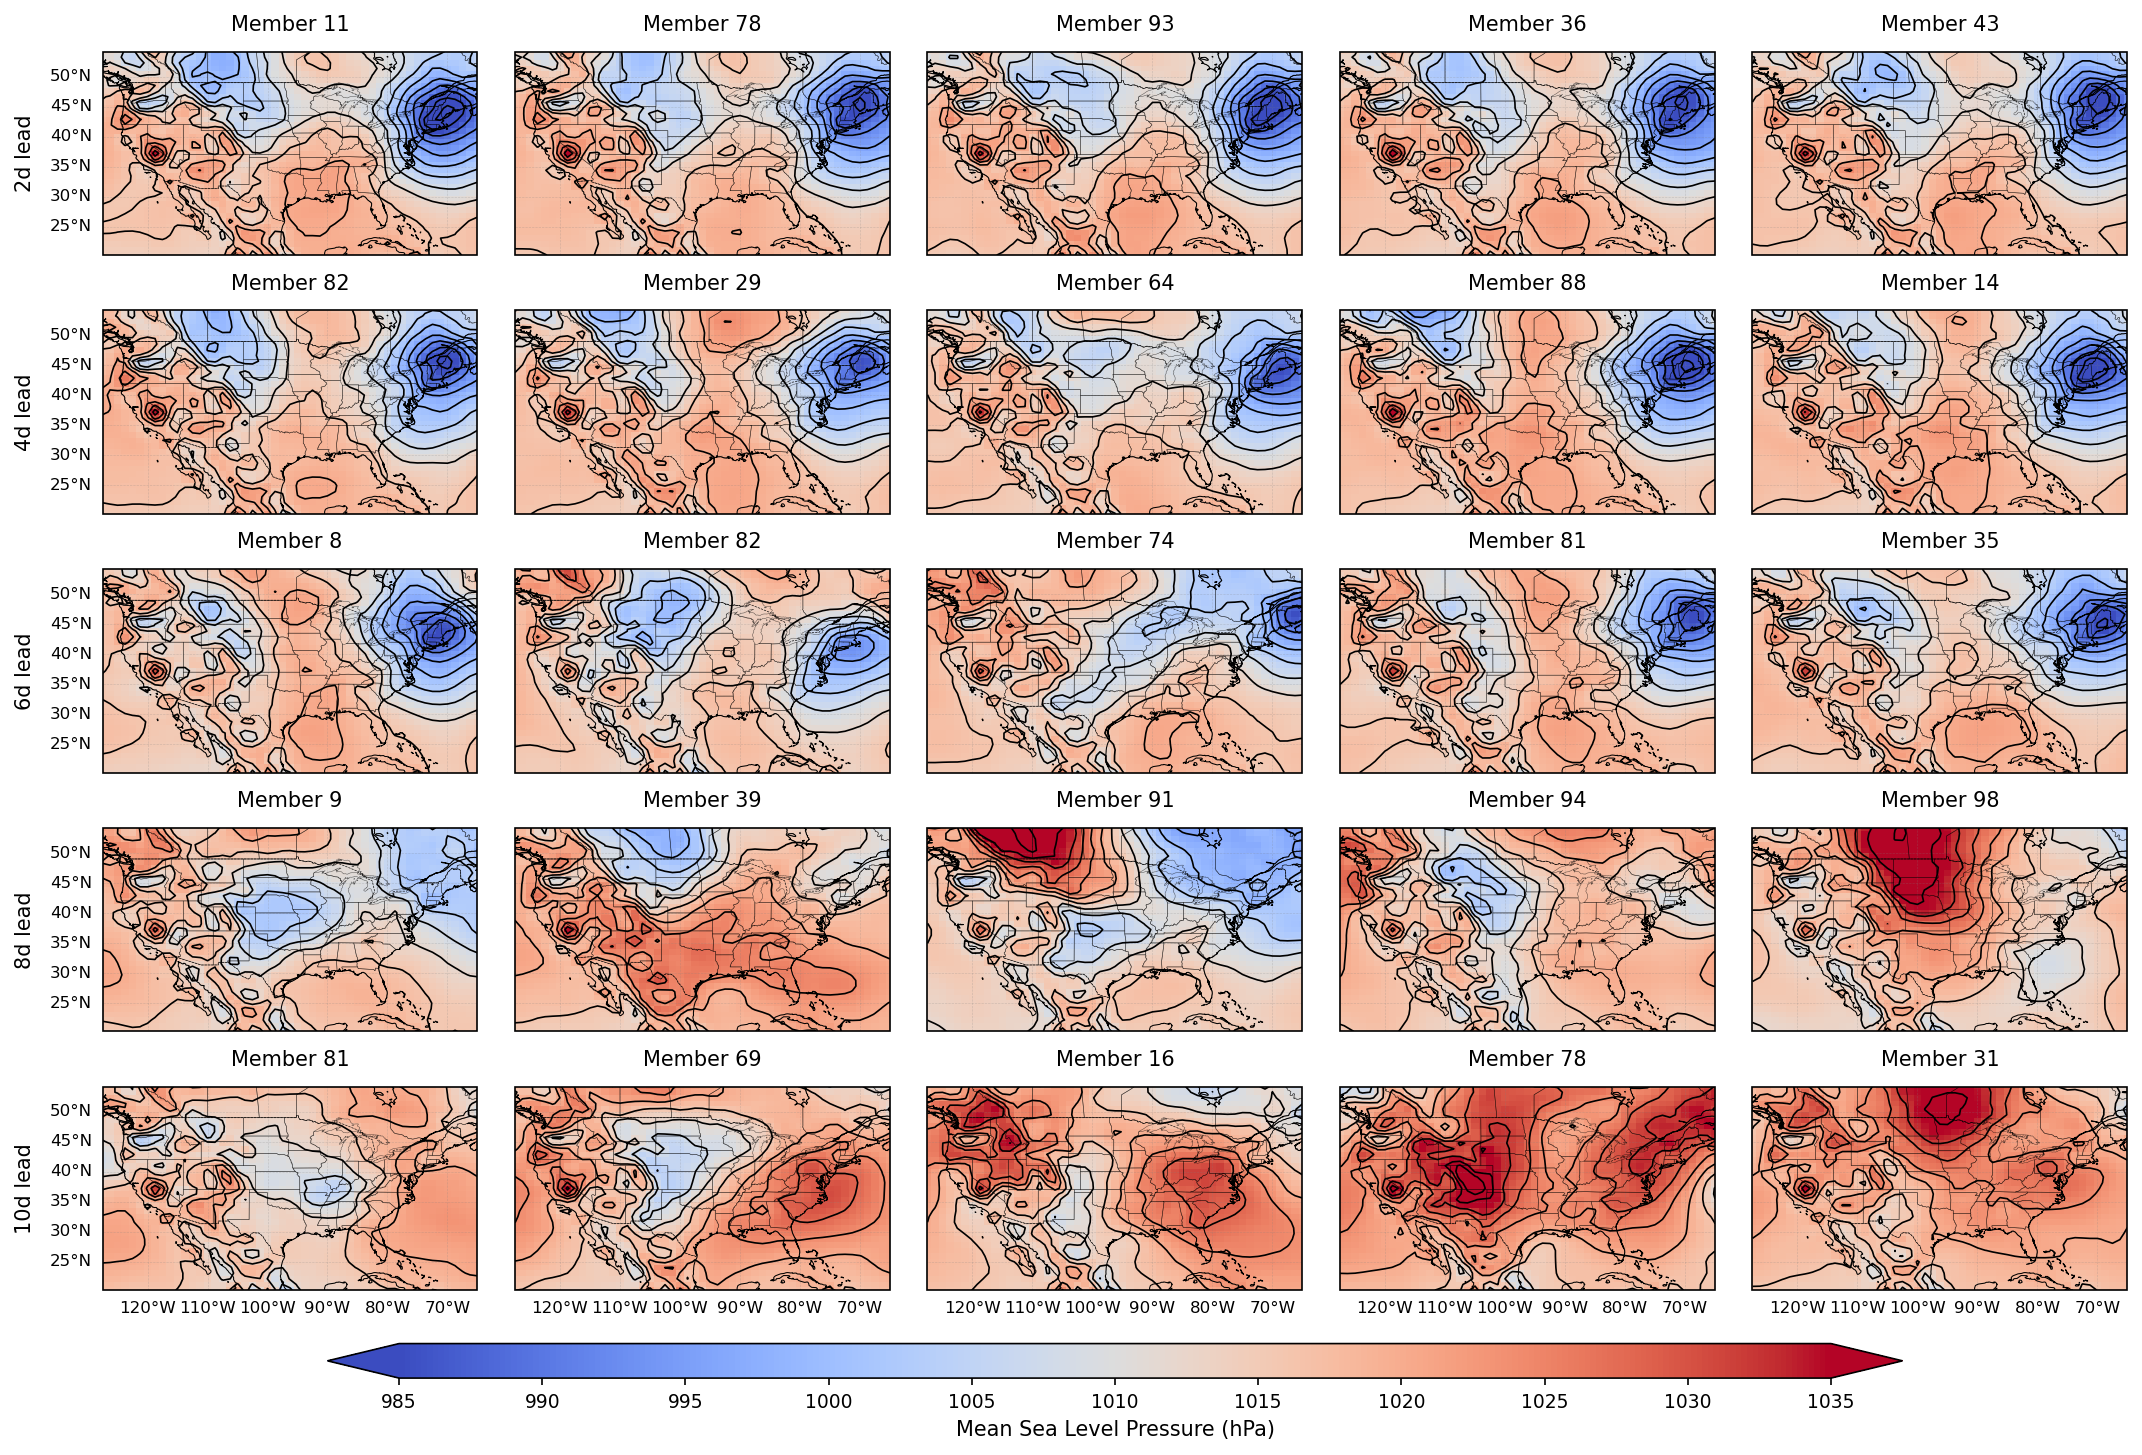

In [2]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter, minimum_filter

# ---------------------------------------------------
# Configuration
# ---------------------------------------------------
base_dir = SCHEDULER_DIR + '/netcdf_pressure_interp'

# Target valid time we want to visualize
target_time = np.datetime64("2022-01-18T00:00:00")

# How many days back to initialize from (lead times)
days_back = [2, 4, 6, 8, 10]

# Number of ensemble members to visualize
N_MEMBERS = 5

# Region of interest
LAT_MIN, LAT_MAX = 20, 55
LON_MIN, LON_MAX = 232, 295  # 0–360 system

# MSLP detection parameters
mslp_smooth_sigma = 1.0 # 1.5
low_neighborhood = 5
low_threshold_pct = 20

# ---------------------------------------------------
# Load sample file for grid information
# ---------------------------------------------------
sample_file = sorted(glob.glob(f"{base_dir}/*/pred_*.nc"))[0]
ds_sample = xr.open_dataset(sample_file)

# Determine coordinate names
lat_name = [v for v in ds_sample.variables if "lat" in v.lower()][0]
lon_name = [v for v in ds_sample.variables if "lon" in v.lower()][0]

# Extract coordinates
lat = ds_sample[lat_name].values
lon = ds_sample[lon_name].values

# Convert longitude to -180 to 180 system
if lon.max() > 180:
    lon = ((lon + 180) % 360) - 180

# Ensure longitude is sorted
sorted_idx = np.argsort(lon)
lon = lon[sorted_idx]

# Determine slicing
lat_ascending = lat[1] > lat[0]
LAT_SLICE = slice(LAT_MAX, LAT_MIN) if not lat_ascending else slice(LAT_MIN, LAT_MAX)
LON_SLICE = slice(max(LON_MIN-360, lon.min()), min(LON_MAX-360, lon.max()))

# Determine MSLP variable name
mslp_name = next((v for v in ds_sample.data_vars if "mslp" in v.lower() or "sea_level" in v.lower()), None)
if not mslp_name:
    raise KeyError("Could not find mean sea level pressure variable in dataset")

ds_sample.close()
# ---------------------------------------------------
# Step 1: Load data for all initialization times
# ---------------------------------------------------
data_dict = {}  # key: days_back, value: dict with 'data' and 'indices'

for days in days_back:
    init_time = target_time - np.timedelta64(days, 'D')
    lead_hours = days*24
    date_str = np.datetime_as_string(init_time, unit="D")
    forecast_file = os.path.join(base_dir, f"{date_str}T00Z", f"pred_{date_str}T00Z_{lead_hours:03d}.nc")

    print(f"Loading {days}d lead: {forecast_file}")

    if not os.path.exists(forecast_file):
        print(f"⚠️ Missing file: {forecast_file}")
        continue

    # Load and process data
    ds = xr.open_dataset(forecast_file)

    # Convert longitude to -180 to 180 and sort
    lon_data = ds[lon_name].values
    if lon_data.max() > 180:
        ds = ds.assign_coords({lon_name: ((lon_data+180)%360)-180})
    ds = ds.isel({lon_name: np.argsort(ds[lon_name].values)})

    # Select spatial subset
    sp = ds[mslp_name].sel(latitude=LAT_SLICE, longitude=LON_SLICE)
    
    # Handle time dimension if present (assume first time step is the valid time)
    if "time" in sp.dims:
        sp = sp.isel(time=0)

    # Select ensemble members based on min MSLP
    selected_idx = [0] # Default to 0 if no ensemble dim
    if "ensemble" in sp.dims:
        n_ens = sp.sizes["ensemble"]
        selected_idx = np.random.choice(n_ens, size=min(N_MEMBERS, n_ens), replace=False)
    
    selected_idx = [int(idx) for idx in selected_idx]
    print(f"  Selected members for {days}d: {selected_idx}")

    # Extract member data as numpy arrays
    member_data = []
    for idx in selected_idx:
        if "ensemble" in sp.dims:
            member_array = sp.isel(ensemble=idx).values
        else:
            member_array = sp.values
        
        member_array = np.squeeze(member_array)
        member_data.append(member_array)

    # Store data for this lead time
    data_dict[days] = {
        "data": member_data,
        "indices": selected_idx,
        "lat": sp.latitude.values,
        "lon": sp.longitude.values
    }
    ds.close()

# Flip latitude and data if latitude is descending
for info in data_dict.values():
    if info["lat"][0] > info["lat"][-1]:
        info["lat"] = info["lat"][::-1]
        info["data"] = [d[::-1,:] for d in info["data"]]

print(f"\nLoaded data for {len(data_dict)} initialization times")

# ---------------------------------------------------
# Step 2: Create the 5x5 figure
# ---------------------------------------------------
nrows = len(days_back)
ncols = N_MEMBERS

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(3 * ncols, 2.3 * nrows),
    dpi=150,
    subplot_kw={"projection": ccrs.PlateCarree()}
)

if nrows == 1: 
    axes = axes.reshape(1, -1)
if ncols == 1: 
    axes = axes.reshape(-1, 1)

pcm = None

# Plot each panel
for r, (days, info) in enumerate(sorted(data_dict.items())):
    lat_sub, lon_sub = info["lat"], info["lon"]
    
    for c in range(len(info["data"])):
        ax = axes[r,c]
        mslp = info["data"][c]
        
        # Smooth the MSLP data
        smoothed = gaussian_filter(mslp, sigma=mslp_smooth_sigma) / 100.0 # Convert to hPa
        
        # Set extent first
        ax.set_extent([lon_sub.min(), lon_sub.max(), lat_sub.min(), lat_sub.max()], ccrs.PlateCarree())
        
        # Map features
        ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="lightgray", zorder=1)
        ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="white", zorder=0)
        ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5, zorder=3)
        ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.3, linestyle="--", zorder=3)
        ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.25, alpha=0.6, zorder=3)
        
        # Background shading (pcolormesh)
        # Background shading (pcolormesh) - DISCRETIZED
        from matplotlib.colors import BoundaryNorm
        
        # Define discrete pressure levels
        n_discrete_levels = 20
        pressure_levels = np.linspace(985, 1035, n_discrete_levels + 1)
        
        # Create discrete colormap and normalization
        cmap_discrete = plt.get_cmap("coolwarm", n_discrete_levels)
        norm = BoundaryNorm(pressure_levels, ncolors=n_discrete_levels, clip=True)
        
        # pcm = ax.pcolormesh(
        #     lon_sub, lat_sub, smoothed, 
        #     cmap=cmap_discrete, norm=norm, shading="auto", 
        #     transform=ccrs.PlateCarree(), zorder=2
        # )
        pcm = ax.pcolormesh(
            lon_sub, lat_sub, smoothed, 
            cmap="coolwarm", vmin=985, vmax=1035, shading="auto", 
            transform=ccrs.PlateCarree(), zorder=2
        )

        # Contours above shading
        ax.contour(
            lon_sub, lat_sub, smoothed, 
            levels=np.arange(980,1041,4), colors="black", linewidths=0.8, 
            transform=ccrs.PlateCarree(), zorder=4
        )

        # Low-pressure markers
        mslp_pa = mslp 
        local_min = minimum_filter(mslp_pa, size=low_neighborhood)
        low_mask = (mslp_pa == local_min)
        thresh = np.nanpercentile(mslp_pa, low_threshold_pct)
        low_mask &= (mslp_pa < thresh)
        
        coords = np.argwhere(low_mask)
        
        # Add gridlines with proper shared axis behavior
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', 
                         alpha=0.3, linestyle='--', zorder=4)
        gl.top_labels = False
        gl.right_labels = False
        
        # Only show y-labels on leftmost column
        gl.left_labels = (c == 0)
        
        # Only show x-labels on bottom row
        gl.bottom_labels = (r == nrows - 1)
        
        gl.xlabel_style = {'size': 8}
        gl.ylabel_style = {'size': 8}
        
        # Title with more padding from the top
        ax.set_title(f"Member {info['indices'][c]}", fontsize=10, pad=10)

        # Row label (initialization info)
        if c==0:
            ax.text(
                -0.18, 0.5, f'{days}d lead', 
                transform=ax.transAxes, rotation=90,
                fontsize=10, ha="right", va="center"
            )

# Adjust layout - negative hspace to overlap rows slightly and eliminate white space
plt.subplots_adjust(left=0.05, right=0.95, top=0.96, bottom=0.06, hspace=-0.5, wspace=0.1)

# Add a single colorbar at the bottom
# Add a single colorbar at the bottom with arrows
cbar_ax = fig.add_axes([0.15, 0.1, 0.7, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', 
                   extend='both', extendfrac=0.05, spacing='uniform')

# Set discrete ticks
cbar.set_ticks(pressure_levels[::2])  # Show every other tick
cbar.set_label('Mean Sea Level Pressure (hPa)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.savefig("ensemble_figure.png", dpi=300, bbox_inches='tight')

plt.show()

### Plot the ensemble metrics for 2022

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import ScalarFormatter

def plot_ensemble_metrics(csv_file, variables_to_plot, output_file='ensemble_metrics.png'):
    """
    Create the multi-panel plot similar to the FCN3 figure
    
    Parameters:
    -----------
    csv_file: str or Path
        Path to CSV file from aggregated_to_csv()
    variables_to_plot: list of variable names (e.g., ['msl', 'u10m', 'z500', 't850', 'u850', 'q700'])
    output_file: str, output filename
    """
    # Read the CSV file
    df = pd.read_csv(csv_file)
    
    # Get unique variables and lead times
    all_variables = df['variable'].unique()
    lead_times = sorted(df['lead_time'].unique())
    
    # Get rank histogram columns
    rank_cols = [c for c in df.columns if c.startswith('rank_')]
    n_members = len(rank_cols)
    n_vars = len(variables_to_plot)
    
    fig = plt.figure(figsize=(15, 7))

    # Outer grid: top 3 rows (CRPS, RMSE, SSR) and bottom (rank)
    outer_gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.2, figure=fig)

    # Inner grids
    top_gs = GridSpecFromSubplotSpec(3, n_vars, subplot_spec=outer_gs[0], hspace=0.2, wspace=0.3)
    bottom_gs = GridSpecFromSubplotSpec(1, n_vars, subplot_spec=outer_gs[1], hspace=0.25, wspace=0.3) # 0.1

    color = '#000000'  # Single model

    # Axes tracking
    ax_crps_list, ax_rmse_list, ax_ssr_list, ax_rank_list = [], [], [], []

    for col, var_name in enumerate(variables_to_plot):
        actual_var = next((v for v in all_variables if var_name.lower() in v.lower()), None)
        if actual_var is None:
            print(f"Warning: Variable {var_name} not found in metrics")
            continue

        print(f"Plotting {var_name} (matched to {actual_var})")
        var_data = df[df['variable'] == actual_var].sort_values('lead_time')

        # Row 1: CRPS
        ax_crps = fig.add_subplot(top_gs[0, col])#, sharex=ax_crps_list[0] if ax_crps_list else None)
        ax_crps_list.append(ax_crps)
        ax_crps.plot(lead_times, var_data['crps'].values, color=color, linewidth=2)
        ax_crps.set_title(var_name, fontsize=10)
        ax_crps.grid(True, alpha=0.3, linewidth=0.5)
        ax_crps.set_xticks([24*d for d in [1, 5, 10, 15]])
        ax_crps.set_xticklabels(["","","",""])
        ax_crps.tick_params(axis='both', which='major', labelsize=9)
        if col == 0:
            ax_crps.set_ylabel('CRPS', fontsize=10)
        # else:
        #     ax_crps.tick_params(labelleft=False)

        # Row 2: RMSE
        ax_rmse = fig.add_subplot(top_gs[1, col])#, sharex=ax_rmse_list[0] if ax_rmse_list else None)
        ax_rmse_list.append(ax_rmse)
        ax_rmse.plot(lead_times, var_data['rmse'].values, color=color, linewidth=2)
        ax_rmse.grid(True, alpha=0.3, linewidth=0.5)
        ax_rmse.set_xticks([24*d for d in [1, 5, 10, 15]])
        ax_rmse.set_xticklabels(["","","",""])
        ax_rmse.tick_params(axis='both', which='major', labelsize=9)
        if col == 0:
            ax_rmse.set_ylabel('RMSE', fontsize=10)
        # else:
        #     ax_rmse.tick_params(labelleft=False)


        # For CRPS axis
        ax_crps.yaxis.set_major_formatter(ScalarFormatter())
        ax_crps.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        
        # For RMSE axis
        ax_rmse.yaxis.set_major_formatter(ScalarFormatter())
        ax_rmse.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

        # Row 3: SSR
        ax_ssr = fig.add_subplot(top_gs[2, col], sharex=ax_ssr_list[0] if ax_ssr_list else None)
        ax_ssr_list.append(ax_ssr)
        values = np.array(var_data['ssr'].values) * ((n_members + 1) / (n_members - 1))
        ax_ssr.plot(lead_times, values, color=color, linewidth=2)
        ax_ssr.axhline(y=1.0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax_ssr.set_xlabel('Lead time (days)', fontsize=10)
        ax_ssr.grid(True, alpha=0.3, linewidth=0.5)
        ax_ssr.set_ylim([0.5, 1.5])
        ax_ssr.set_xticks([24*d for d in [1, 5, 10, 15]])
        ax_ssr.set_xticklabels(['1', '5', '10', '15'])
        ax_ssr.tick_params(axis='both', which='major', labelsize=9)
        if col == 0:
            ax_ssr.set_ylabel('SSR', fontsize=10)
        else:
            ax_ssr.tick_params(labelleft=False)

        # Bottom row: Rank histogram
        ax_rank = fig.add_subplot(bottom_gs[0, col], sharey=ax_rank_list[0] if ax_rank_list else None)
        ax_rank_list.append(ax_rank)
        lead_indices_to_show = {6: ('6h', 'purple'), 120: ('5d', 'blue'),
                                240: ('10d', 'orange'), 360: ('15d', 'green')}
        markers = ["o", "s", "^", "d"]
        count = 0
        for lead_hour, (label, color_line) in lead_indices_to_show.items():
            if lead_hour in lead_times:
                row_data = var_data[var_data['lead_time'] == lead_hour]
                if len(row_data) > 0:
                    rank_freq = row_data[rank_cols].values[0]
                    if not np.all(np.isnan(rank_freq)):
                        ranks = np.arange(len(rank_freq))
                        ax_rank.plot(ranks, rank_freq, color=color_line,
                                     marker=markers[count], linewidth=1.5, markersize=3, markevery=10,
                                     label=label if col == n_vars - 1 else "")
                        ax_rank.set_xticks(list(range(0, 101, 25)))
                        # ax_rank.set_xticklabels(["","","",""])
                        count += 1
        uniform_level = 1.0 / n_members
        ax_rank.axhline(y=uniform_level, color='#000000', linestyle='--', linewidth=1, alpha=0.5)
        ax_rank.set_xlabel('Rank', fontsize=10)
        ax_rank.grid(True, alpha=0.3, linewidth=0.5)
        ax_rank.set_ylim([0, 0.04])
        ax_rank.tick_params(axis='both', which='major', labelsize=9)
        if col == 0:
            ax_rank.set_ylabel('Frequency', fontsize=10)
        else:
            ax_rank.tick_params(labelleft=False)
        
        if col == n_vars - 1:
            legend = ax_rank.legend(
                fontsize=10,          # text size
                loc='upper right',    # position
                framealpha=0.9,       # box transparency
                ncol=2,               # number of columns
                columnspacing=0.5,    # space between columns
                handlelength=0.2,       # length of the line/marker in legend
                handletextpad=0.8,    # space between handle (line/marker) and text
                borderpad=0.5,        # padding between legend content and border
                labelspacing=0.5      # vertical space between entries
            )
            # remove legend lines if needed
            for legline in legend.get_lines():
                legline.set_linewidth(0)


    # Save or show
    # plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()


In [38]:
filename = SCHEDULER_DIR + '/netcdf_pressure_interp/metrics/average_performance_bootstrap.csv'
ifs_filename = SCHEDULER_DIR + '/netcdf_1000/metrics/ifs_average_performance.csv'
df = pd.read_csv(filename)

In [4]:
df

,variable,lead_time,crps,rmse,spread,ssr,acc,mse,mae,rank_0,...,rank_91,rank_92,rank_93,rank_94,rank_95,rank_96,rank_97,rank_98,rank_99,rank_100
0,U_0,6,1.927928,3.543761,2.762804,0.796398,0.994634,12.887035,2.681185,0.026919,...,0.010470,0.010675,0.010935,0.011254,0.011565,0.012089,0.012870,0.014105,0.016522,0.028259
1,U_0,12,2.752341,5.027833,3.578384,0.731123,0.989450,26.158099,3.790599,0.033438,...,0.010822,0.011139,0.011533,0.012018,0.012635,0.013402,0.014604,0.016567,0.020493,0.040702
2,U_0,18,3.164897,5.818521,4.132780,0.732032,0.986252,35.198918,4.356262,0.035841,...,0.010388,0.010697,0.011052,0.011440,0.012047,0.012737,0.013723,0.015390,0.019066,0.037634
3,U_0,24,3.659736,6.724777,4.634707,0.713170,0.981996,47.297340,5.018561,0.041126,...,0.010491,0.010823,0.011290,0.011734,0.012366,0.013174,0.014409,0.016398,0.020635,0.043197
4,U_0,30,3.964739,7.315216,5.004500,0.706791,0.978293,55.936181,5.429958,0.040893,...,0.010599,0.010945,0.011318,0.011791,0.012469,0.013322,0.014556,0.016563,0.020913,0.044902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5215,mean_sea_level_pressure,336,303.574975,677.233688,656.222615,0.975078,0.874578,462221.899039,432.855682,0.012138,...,0.010863,0.011016,0.011207,0.011483,0.011734,0.012054,0.012500,0.013196,0.014341,0.017025
5216,mean_sea_level_pressure,342,303.697726,678.873775,658.215728,0.975665,0.875111,464453.111464,433.051399,0.011903,...,0.010908,0.011039,0.011159,0.011431,0.011689,0.011964,0.012389,0.013140,0.013941,0.016293
5217,mean_sea_level_pressure,348,305.770673,682.307351,661.476072,0.975569,0.872651,469167.654491,435.876223,0.012225,...,0.010783,0.010866,0.011112,0.011403,0.011780,0.012050,0.012333,0.012884,0.013959,0.016751
5218,mean_sea_level_pressure,354,306.373255,683.804230,663.173171,0.975931,0.873064,471200.803926,436.629488,0.011843,...,0.010766,0.010868,0.011022,0.011298,0.011551,0.011881,0.012251,0.012926,0.014164,0.016618


In [5]:
# plot_ensemble_metrics(filename, ['t2m','V500','U500','T500','Z500','Q500'])

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import LinearSegmentedColormap
import cmcrameri.cm as cmc


def plot_ensemble_levels(csv_file, variables_to_plot, output_file='figure2.png'):
    """
    Plot CRPS, RMSE, SSR, and Rank histograms for multiple vertical levels for U, V, T, Q.

    Parameters:
    -----------
    csv_file : str or Path
        CSV file with columns: variable, lead_time, crps, rmse, ssr, rank_0 ... rank_100
    variables_to_plot : list
        Variables to plot ['U', 'V', 'T', 'Q']
    output_file : str
        Filename to save the figure
    """
    df = pd.read_csv(csv_file)
    lead_times = sorted(df['lead_time'].unique())
    rank_cols = [c for c in df.columns if c.startswith('rank_')]
    n_members = len(rank_cols)
    
    n_vars = len(variables_to_plot)
    
    # Better color scheme - use a perceptually uniform colormap
    # Option 1: Viridis (good for colorblind)
    # Option 2: Plasma (more vibrant)
    # Option 3: Custom diverging from blue (surface) to red (top)
    labeldict = {
        "U": "U (m/s)",
        "V": "V (m/s)",
        "T": "T (K)",
        "Q": "Q (kg/kg)"
    }
    
    fig = plt.figure(figsize=(13, 14))
    
    # Top: CRPS, RMSE, SSR for each variable
    # Bottom: 4 rows of rank histograms (one per lead time) x n_vars columns
    outer_gs = GridSpec(2, 1, height_ratios=[3, 4], hspace=0.3, figure=fig)
    top_gs = GridSpecFromSubplotSpec(3, n_vars, subplot_spec=outer_gs[0], hspace=0.2, wspace=0.2)
    bottom_gs = GridSpecFromSubplotSpec(4, n_vars, subplot_spec=outer_gs[1], hspace=0.275, wspace=0.2)
    
    lead_indices_to_show = {6: ('6h', 0), 120: ('5d', 1), 240: ('10d', 2), 360: ('15d', 3)}
    lead_colors = {6: '#9467bd', 120: '#1f77b4', 240: '#ff7f0e', 360: '#2ca02c'}
    
    for col, var_prefix in enumerate(variables_to_plot):
        # Get all vertical levels for this variable
        var_levels = sorted([v for v in df['variable'].unique() if v.startswith(f"{var_prefix}_") and "PRES" not in v])
        if not var_levels:
            print(f"Warning: No variables found for {var_prefix}")
            continue
        
        n_levels = len(var_levels)
        # Create color gradient using viridis - good contrast and colorblind-friendly
        # colors = plt.cm.cividis(np.linspace(0.0, 1.0, n_levels))
        colors = cmc.batlow_r(np.linspace(0.0, 1.0, n_levels))  # Note the '_r' for reverse
        
        # --- CRPS ---
        ax_crps = fig.add_subplot(top_gs[0, col])
        for i, lvl in enumerate(var_levels):
            data_lvl = df[df['variable'] == lvl].sort_values('lead_time')
            ax_crps.plot(lead_times, data_lvl['crps'].values, 
                        linewidth=1.5, alpha=1.0, color=colors[i])
        ax_crps.set_title(labeldict[var_prefix], fontsize=10)
        if col == 0:
            ax_crps.set_ylabel('CRPS', fontsize=10)
        # else:
        #     ax_crps.tick_params(labelleft=False)
        ax_crps.grid(True, alpha=0.3, linewidth=0.5)
        ax_crps.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        ax_crps.yaxis.get_offset_text().set_fontsize(8)
        ax_crps.set_xticks([24*d for d in [1,5,10,15]])
        ax_crps.set_xticklabels(["","","",""])
        ax_crps.tick_params(axis='both', which='major', labelsize=9)
        plt.setp(ax_crps.get_xticklabels(), visible=False)
        
        # --- RMSE ---
        ax_rmse = fig.add_subplot(top_gs[1, col], sharex=ax_crps)
        for i, lvl in enumerate(var_levels):
            data_lvl = df[df['variable'] == lvl].sort_values('lead_time')
            ax_rmse.plot(lead_times, data_lvl['rmse'].values, 
                        linewidth=1.5, alpha=0.85, color=colors[i])
        if col == 0:
            ax_rmse.set_ylabel('RMSE', fontsize=10)
        # else:
        #     ax_rmse.tick_params(labelleft=False)
        
        ax_rmse.grid(True, alpha=0.3, linewidth=0.5)
        ax_rmse.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        ax_rmse.yaxis.get_offset_text().set_fontsize(8)
        ax_rmse.set_xticks([24*d for d in [1,5,10,15]])
        ax_rmse.set_xticklabels(["","","",""])
        ax_rmse.tick_params(axis='both', which='major', labelsize=9)
        plt.setp(ax_rmse.get_xticklabels(), visible=False)

        if var_prefix == "Q":
            ax_crps.set_yscale('log')
            ax_rmse.set_yscale('log')
        
        # --- SSR ---
        ax_ssr = fig.add_subplot(top_gs[2, col], sharex=ax_crps)
        for i, lvl in enumerate(var_levels):
            data_lvl = df[df['variable'] == lvl].sort_values('lead_time')
            values = np.array(data_lvl['ssr'].values) * ((n_members + 1) / (n_members - 1))
            ax_ssr.plot(lead_times, values, linewidth=1.5, alpha=0.85, color=colors[i])
        ax_ssr.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=1.0)
        if col == 0:
            ax_ssr.set_ylabel('SSR', fontsize=10)
        # else:
        #     ax_ssr.tick_params(labelleft=False)
        ax_ssr.set_xlabel('Lead time (days)', fontsize=10)
        ax_ssr.grid(True, alpha=0.3, linewidth=0.5)
        if var_prefix == "Q":
            ax_ssr.set_ylim([0, 1.15])
        else:
            ax_ssr.set_ylim([0.6, 1.15])
        ax_ssr.set_xticks([24*d for d in [1,5,10,15]])
        ax_ssr.set_xticklabels(['1','5','10','15'])
        ax_ssr.tick_params(axis='both', which='major', labelsize=9)
        
        # --- Rank histograms: One subplot per lead time ---
        for lead_hour, (label, row_idx) in lead_indices_to_show.items():
            if row_idx == 0 and col == 0:
                ax_rank = fig.add_subplot(bottom_gs[row_idx, col])
                ax_rank_first = ax_rank
            elif row_idx == 0:
                ax_rank = fig.add_subplot(bottom_gs[row_idx, col], sharey=ax_rank_first)
            else:
                ax_rank = fig.add_subplot(bottom_gs[row_idx, col], sharey=ax_rank_first)
            
            if lead_hour in lead_times:
                for i, lvl in enumerate(var_levels):
                    data_lvl = df[df['variable'] == lvl]
                    row = data_lvl[data_lvl['lead_time'] == lead_hour]
                    if len(row) > 0:
                        rank_freq = row[rank_cols].values[0]
                        if not np.all(np.isnan(rank_freq)):
                            ranks = np.arange(len(rank_freq))
                            ax_rank.plot(ranks, rank_freq, linewidth=1.2, 
                                       alpha=0.7, color=colors[i])
            
            # Uniform reference line
            uniform_level = 1.0 / n_members
            ax_rank.axhline(y=uniform_level, color='#000000', linestyle='--', 
                          linewidth=1.5, alpha=1.0)
            
            # Labels
            if col == 0:
                ax_rank.set_ylabel(label, fontsize=10)
            else:
                ax_rank.tick_params(labelleft=False)
            
            if row_idx == 3:  # Bottom row
                ax_rank.set_xlabel('Rank', fontsize=10)
            else:
                ax_rank.tick_params(labelbottom=False)
            
            ax_rank.grid(True, alpha=0.3, linewidth=0.5)
            ax_rank.set_ylim([0, 0.04])
            ax_rank.set_xticks(list(range(0, 101, 25)))
            ax_rank.tick_params(axis='both', which='major', labelsize=9)
    
    # Add colorbar horizontally between top and bottom sections
    cbar_ax = fig.add_axes([0.15, 0.535, 0.7, 0.015])  # [left, bottom, width, height]
    sm = plt.cm.ScalarMappable(cmap=cmc.batlow_r, 
                               norm=plt.Normalize(vmin=0, vmax=n_levels-1))
    sm.set_array([])
    # levels = [10, 30, 40, 50, 60, 70, 80, 90, 95, 100, 105, 110, 120, 130, 136, 137]
    levels = [20, 70, 100, 150, 200, 300, 400, 500, 600, 700, 800, 850, 925, 975, 1000, 1013]
    cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal', boundaries=np.arange(n_levels+1)-0.5, ticks=np.arange(n_levels))
    cbar.set_label('Model level (hPa)', fontsize=10)
    cbar.ax.tick_params(labelsize=8)
    cbar.ax.set_xticklabels(levels)
    plt.tight_layout()
    plt.savefig(output_file, dpi=600, bbox_inches='tight')
    # plt.close(fig)
    # print(f"Plot saved to {output_file}")
    plt.show()

/glade/derecho/scratch/schreck/tmp/ipykernel_154749/2106297732.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


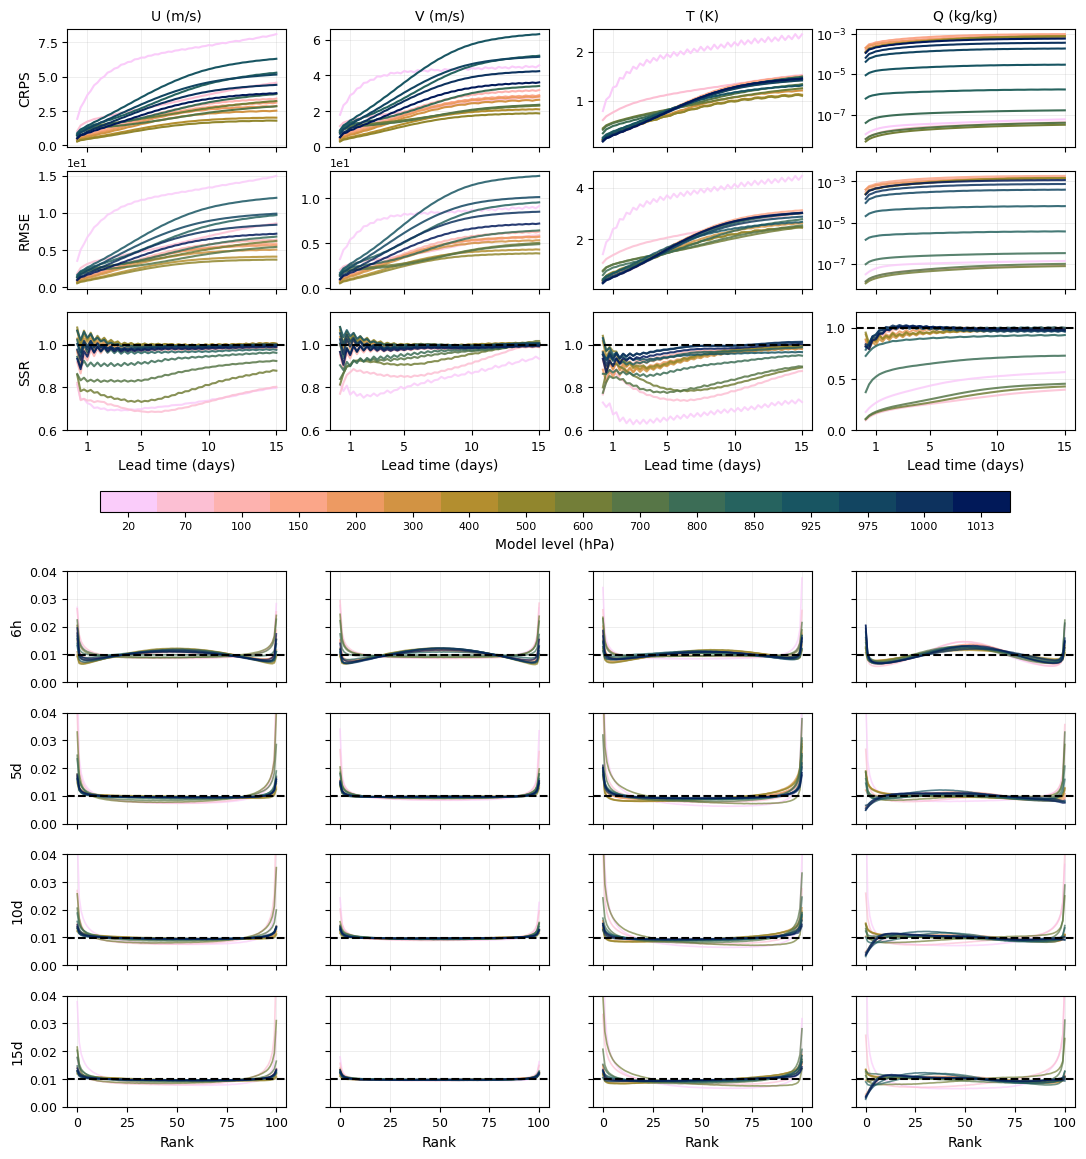

In [44]:
plot_ensemble_levels(filename, ["U", "V", "T", "Q"])

In [11]:
#plot_ensemble_levels(filename, ["U", "V", "T", "Q"])

### Add IFS to the figures

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

def plot_ensemble_metrics(csv_file, variables_to_plot, output_file='ensemble_metrics.png', ifs_file=None):
    """
    Multi-panel ensemble verification plot (CRPS, RMSE, SSR, rank histograms)
    with optional IFS reference.
    """

    def parse_var_level(var_name):
        import re
        name = var_name.lower()
        
        # Handle special cases
        if 't2m' in name:
            return 't2m', None
        if 'mean_sea_level_pressure' in name or 'mslp' in name:
            return 'mslp', None
        
        # Extract level - look for any sequence of digits
        m = re.search(r'(\d+)', var_name)
        level = float(m.group(1)) if m else None
        
        # Extract base variable name - get letters before any digits or underscores
        base_match = re.match(r'^([A-Za-z]+)', var_name)
        base = base_match.group(1).upper() if base_match else var_name.split('_')[0].upper()
        
        return base, level

    var_map = {
        't2m': '2m_temperature',
        'mslp': 'mean_sea_level_pressure',
        'T': 'temperature',
        'Q': 'specific_humidity',
        'U': 'u_component_of_wind',
        'V': 'v_component_of_wind',
        'Z': 'geopotential'
    }

    df = pd.read_csv(csv_file)
    lead_times = np.sort(df['lead_time'].unique())
    lead_times_days = lead_times / 24
    rank_cols = [c for c in df.columns if c.startswith('rank_')]
    n_members = len(rank_cols)
    n_members_ifs = 50

    if ifs_file is not None:
        ifs_df = pd.read_csv(ifs_file)
    else:
        ifs_df = None

    n_vars = len(variables_to_plot)
    fig = plt.figure(figsize=(15, 9))
    outer_gs = GridSpec(2, 1, height_ratios=[3, 2], hspace=0.1, figure=fig)
    top_gs = GridSpecFromSubplotSpec(3, n_vars, subplot_spec=outer_gs[0], hspace=0.25, wspace=0.3)
    bottom_gs = GridSpecFromSubplotSpec(2, n_vars, subplot_spec=outer_gs[1], hspace=0.25, wspace=0.3)

    color_pred = '#000000'
    color_ifs = '#0066CC'

    for col, var_name in enumerate(variables_to_plot):
        all_vars = df['variable'].unique()
        
        # Try multiple matching strategies
        actual_var = None
        
        # Strategy 1: Direct substring match (works for 'V500', 't2m', etc.)
        actual_var = next((v for v in all_vars if var_name.lower() in v.lower()), None)
        
        # Strategy 2: Handle PRES format (U850 -> U_PRES_850mb)
        if actual_var is None:
            var_base, level = parse_var_level(var_name)
            if level is not None:
                # Try U_PRES_850mb format
                candidate = f"{var_base}_PRES_{int(level)}mb"
                if candidate in all_vars:
                    actual_var = candidate
                # Try lowercase version
                elif candidate.lower() in [v.lower() for v in all_vars]:
                    actual_var = next(v for v in all_vars if v.lower() == candidate.lower())
        
        if actual_var is None:
            print(f"Warning: {var_name} not found in file — skipping.")
            continue

        var_data = df[df['variable'] == actual_var].sort_values('lead_time')

        has_ifs = False
        aligned_ifs = {}
        ifs_match = None
        if ifs_df is not None:
            var_base, level = parse_var_level(var_name)
            ifs_var = var_map.get(var_base)
            
            if ifs_var:
                if level is None:
                    ifs_match = ifs_df[ifs_df['variable'] == ifs_var].sort_values('lead_time_hours')
                else:
                    # More robust level matching - handle both int and float types
                    # Try exact match first, then close match
                    ifs_match = ifs_df[
                        (ifs_df['variable'] == ifs_var) & 
                        (ifs_df['level'] == level)
                    ].sort_values('lead_time_hours')
                    
                    # If no exact match, try with tolerance
                    if ifs_match.empty:
                        ifs_match = ifs_df[
                            (ifs_df['variable'] == ifs_var) &
                            (np.abs(ifs_df['level'] - level) < 1.0)
                        ].sort_values('lead_time_hours')
                
                if not ifs_match.empty:
                    aligned_ifs = {
                        k: np.interp(lead_times, ifs_match['lead_time_hours'], ifs_match[k])
                        for k in ['crps', 'rmse', 'ssr']
                        if k in ifs_match.columns
                    }
                    has_ifs = True
                else:
                    print(f"Warning: No IFS match for {var_name} (var={ifs_var}, level={level})")

        # --- CRPS ---
        ax_crps = fig.add_subplot(top_gs[0, col])
        if has_ifs and 'crps' in aligned_ifs:
            ax_crps.plot(lead_times_days, aligned_ifs['crps'], color=color_ifs, ls='--', lw=2.5, label='IFS')
        ax_crps.plot(lead_times_days, var_data['crps'], color=color_pred, lw=2.5, label='Predicted')
        ax_crps.set_title(var_name, fontsize=10)
        ax_crps.grid(True, alpha=0.3)
        ax_crps.set_xticks([1,5,10,15])
        ax_crps.set_xticklabels(["","","",""])
        if col == 0:
            ax_crps.set_ylabel('CRPS', fontsize=10)
            ax_crps.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax_crps.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

        # --- RMSE ---
        ax_rmse = fig.add_subplot(top_gs[1, col])
        if has_ifs and 'rmse' in aligned_ifs:
            ax_rmse.plot(lead_times_days, aligned_ifs['rmse'], color=color_ifs, ls='--', lw=2.5)
        ax_rmse.plot(lead_times_days, var_data['rmse'], color=color_pred, lw=2.5)
        ax_rmse.grid(True, alpha=0.3)
        ax_rmse.set_xticks([1,5,10,15])
        ax_rmse.set_xticklabels(["","","",""])
        if col == 0:
            ax_rmse.set_ylabel('RMSE', fontsize=10)
            ax_rmse.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax_rmse.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

        # --- SSR ---
        ax_ssr = fig.add_subplot(top_gs[2, col])
        ssr_pred = np.array(var_data['ssr']) * ((n_members + 1) / (n_members - 1))
        ax_ssr.plot(lead_times_days, ssr_pred, color=color_pred, lw=2.5)
        if has_ifs and 'ssr' in aligned_ifs:
            ssr_ifs = np.array(aligned_ifs['ssr']) * ((n_members_ifs + 1) / (n_members_ifs - 1))
            ax_ssr.plot(lead_times_days, ssr_ifs, color=color_ifs, ls='--', lw=2.5)
        ax_ssr.axhline(1.0, color='black', ls='--', lw=1, alpha=0.5)
        ax_ssr.grid(True, alpha=0.3)
        ax_ssr.set_ylim([0.5, 1.5])
        ax_ssr.set_xticks([1,5,10,15])
        ax_ssr.set_xticklabels(["","","",""])
        if col == 0:
            ax_ssr.set_ylabel('SSR', fontsize=10)
        ax_ssr.set_xlabel('Lead time (days)', fontsize=10)

        # --- Rank histograms (Model Prediction - Row 4) ---
        ax_rank_pred = fig.add_subplot(bottom_gs[0, col])
        lead_indices_to_show = {6: ('6h','purple'), 120: ('5d','blue'),
                                240: ('10d','orange'), 360: ('15d','green')}
        markers = ["o","s","^","d"]

        for count, (lead_hour,(label,c)) in enumerate(lead_indices_to_show.items()):
            if lead_hour in lead_times:
                row = var_data[var_data['lead_time'] == lead_hour]
                if len(row) == 1:
                    vals = row[rank_cols].values[0]
                    if not np.all(np.isnan(vals)):
                        ax_rank_pred.plot(np.arange(len(rank_cols)), vals, color=c,
                                     marker=markers[count], lw=1.5, ms=3, markevery=10,
                                     label=label if col==n_vars-1 else "")

        ax_rank_pred.axhline(1.0/n_members, color='black', ls='--', lw=1, alpha=0.5)
        ax_rank_pred.grid(True, alpha=0.3)
        ax_rank_pred.set_ylim([0, 0.04])
        ax_rank_pred.set_xlabel('Rank', fontsize=10)
        if col == 0: ax_rank_pred.set_ylabel('Model\nFrequency', fontsize=10)
        if col == n_vars - 1:
            leg = ax_rank_pred.legend(fontsize=9, loc='upper right', framealpha=0.9, ncol=2)
            for line in leg.get_lines():
                line.set_linewidth(0)

        # --- Rank histograms (IFS - Row 5) ---
        ax_rank_ifs = fig.add_subplot(bottom_gs[1, col])
        
        # Get IFS rank columns
        ifs_rank_cols = []
        if has_ifs and ifs_match is not None:
            ifs_rank_cols = [c for c in ifs_match.columns if c.startswith('rank_')]
        
        if has_ifs and len(ifs_rank_cols) > 0:
            for count, (lead_hour,(label,c)) in enumerate(lead_indices_to_show.items()):
                if lead_hour in lead_times:
                    # Find the IFS row for this lead time
                    idx = list(lead_times).index(lead_hour)
                    if idx < len(ifs_match):
                        ifs_vals = ifs_match.iloc[idx][ifs_rank_cols].values.astype(float)
                        # Normalize by sum
                        ifs_vals_normalized = ifs_vals / np.sum(ifs_vals) if np.sum(ifs_vals) > 0 else ifs_vals
                        if not np.all(np.isnan(ifs_vals_normalized)):
                            # Plot on IFS's own rank axis (0 to n_members_ifs)
                            ifs_ranks = np.arange(len(ifs_rank_cols))
                            ax_rank_ifs.plot(ifs_ranks, ifs_vals_normalized, color=c, 
                                           marker=markers[count], lw=1.5, ms=3, markevery=5)

            ax_rank_ifs.axhline(1.0/n_members_ifs, color='black', ls='--', lw=1, alpha=0.5)
        
        ax_rank_ifs.grid(True, alpha=0.3)
        ax_rank_ifs.set_xticks([0, 25, 50])
        ax_rank_ifs.set_ylim([0, 0.1])
        ax_rank_ifs.set_xlabel('Rank', fontsize=10)
        if col == 0: ax_rank_ifs.set_ylabel('IFS\nFrequency', fontsize=10)

    plt.tight_layout()
    plt.show()

/glade/derecho/scratch/schreck/tmp/ipykernel_82925/3768500307.py:226: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


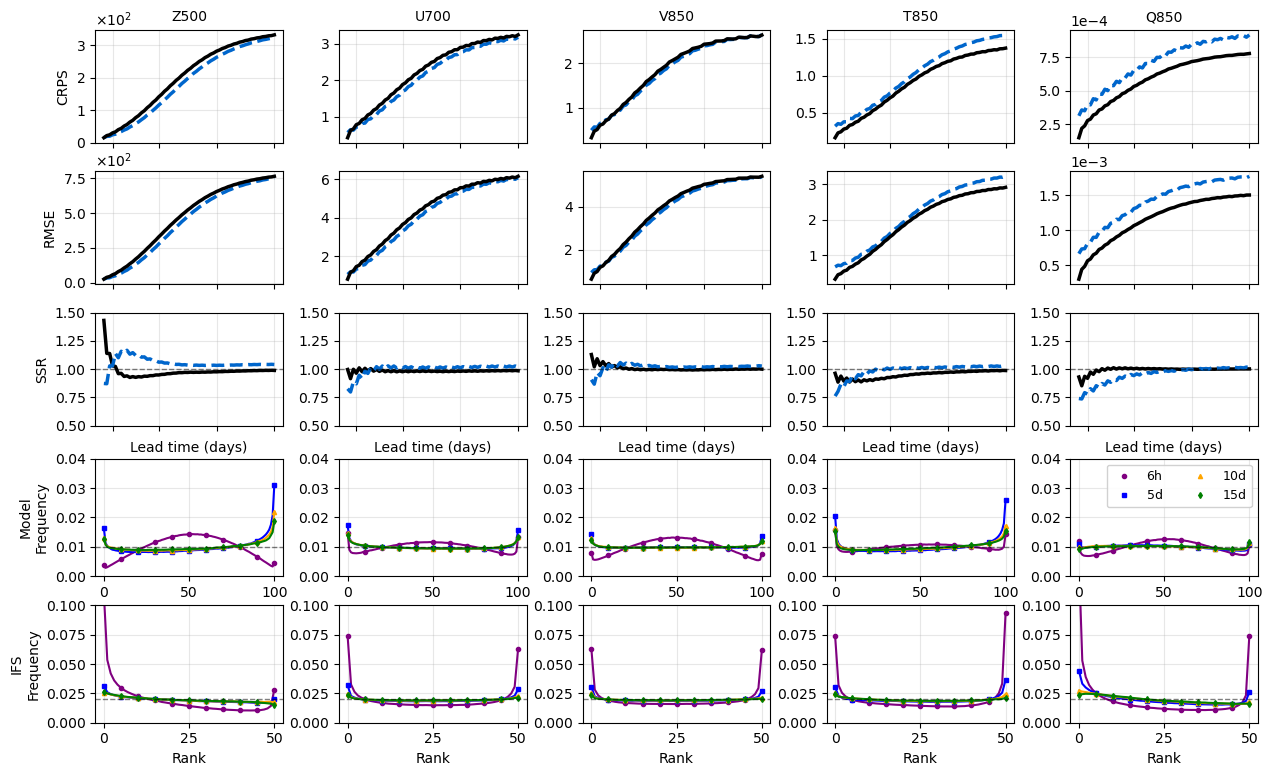

In [13]:
plot_ensemble_metrics(
    filename,
    ['Z500', 'U700', 'V850','T850', 'Q850'], # ['Z500', 'U500', 'V700','T500', 'Q700']
    ifs_file=ifs_filename
)

### Deterministic results with ensemble

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

def plot_ensemble_metrics(csv_file, variables_to_plot, output_file='ensemble_metrics.png', 
                          ifs_file=None, deterministic_file=None, ifs_deterministic_file=None):
    """
    Multi-panel ensemble verification plot (CRPS, RMSE, SSR, rank histograms)
    with optional IFS reference and deterministic metrics.
    """

    def parse_var_level(var_name):
        import re
        name = var_name.lower()
        
        # Handle special cases
        if 't2m' in name:
            return 't2m', None
        if 'mean_sea_level_pressure' in name or 'mslp' in name:
            return 'mslp', None
        
        # Extract level - look for any sequence of digits
        m = re.search(r'(\d+)', var_name)
        level = float(m.group(1)) if m else None
        
        # Extract base variable name - get letters before any digits or underscores
        base_match = re.match(r'^([A-Za-z]+)', var_name)
        base = base_match.group(1).upper() if base_match else var_name.split('_')[0].upper()
        
        return base, level

    def get_units(var_name):
        """Get appropriate units for variable name"""
        var_base, level = parse_var_level(var_name)
        
        unit_map = {
            'Z': 'm',
            'U': 'm/s',
            'V': 'm/s',
            'T': 'K',
            'Q': 'kg/kg',
            't2m': 'K',
            'mslp': 'Pa'
        }
        
        return unit_map.get(var_base, '')

    var_map = {
        't2m': '2m_temperature',
        'mslp': 'mean_sea_level_pressure',
        'T': 'temperature',
        'Q': 'specific_humidity',
        'U': 'u_component_of_wind',
        'V': 'v_component_of_wind',
        'Z': 'geopotential'
    }

    df = pd.read_csv(csv_file)
    lead_times = np.sort(df['lead_time'].unique())
    lead_times_days = lead_times / 24
    rank_cols = [c for c in df.columns if c.startswith('rank_')]
    n_members = len(rank_cols)
    n_members_ifs = 50

    if ifs_file is not None:
        ifs_df = pd.read_csv(ifs_file)
    else:
        ifs_df = None

    # Load deterministic files
    if deterministic_file is not None:
        det_df = pd.read_csv(deterministic_file)
    else:
        det_df = None
        
    if ifs_deterministic_file is not None:
        ifs_det_df = pd.read_csv(ifs_deterministic_file)
    else:
        ifs_det_df = None

    n_vars = len(variables_to_plot)
    
    # Adjust figure height and layout
    fig = plt.figure(figsize=(15, 10))
    outer_gs = GridSpec(2, 1, height_ratios=[4, 2], hspace=0.15, figure=fig)
    
    # Top rows: All metrics (RMSE det, RMSE ens, CRPS, SSR)
    top_gs = GridSpecFromSubplotSpec(4, n_vars, subplot_spec=outer_gs[0], hspace=0.25, wspace=0.225)
    
    # Bottom rows: Rank histograms
    bottom_gs = GridSpecFromSubplotSpec(2, n_vars, subplot_spec=outer_gs[1], hspace=0.25, wspace=0.225)

    color_pred = '#000000'
    color_ifs = '#0066CC'

    for col, var_name in enumerate(variables_to_plot):
        all_vars = df['variable'].unique()
        
        # Try multiple matching strategies
        actual_var = None
        
        # Strategy 1: Direct substring match (works for 'V500', 't2m', etc.)
        actual_var = next((v for v in all_vars if var_name.lower() in v.lower()), None)
        
        # Strategy 2: Handle PRES format (U850 -> U_PRES_850mb)
        if actual_var is None:
            var_base, level = parse_var_level(var_name)
            if level is not None:
                # Try U_PRES_850mb format
                candidate = f"{var_base}_PRES_{int(level)}mb"
                if candidate in all_vars:
                    actual_var = candidate
                # Try lowercase version
                elif candidate.lower() in [v.lower() for v in all_vars]:
                    actual_var = next(v for v in all_vars if v.lower() == candidate.lower())
        
        if actual_var is None:
            print(f"Warning: {var_name} not found in file — skipping.")
            continue

        var_data = df[df['variable'] == actual_var].sort_values('lead_time')

        # Match IFS ensemble data
        has_ifs = False
        aligned_ifs = {}
        ifs_match = None
        if ifs_df is not None:
            var_base, level = parse_var_level(var_name)
            ifs_var = var_map.get(var_base)
            
            if ifs_var:
                if level is None:
                    ifs_match = ifs_df[ifs_df['variable'] == ifs_var].sort_values('lead_time_hours')
                else:
                    ifs_match = ifs_df[
                        (ifs_df['variable'] == ifs_var) & 
                        (ifs_df['level'] == level)
                    ].sort_values('lead_time_hours')
                    
                    if ifs_match.empty:
                        ifs_match = ifs_df[
                            (ifs_df['variable'] == ifs_var) &
                            (np.abs(ifs_df['level'] - level) < 1.0)
                        ].sort_values('lead_time_hours')
                
                if not ifs_match.empty:
                    aligned_ifs = {
                        k: np.interp(lead_times, ifs_match['lead_time_hours'], ifs_match[k])
                        for k in ['crps', 'rmse', 'ssr']
                        if k in ifs_match.columns
                    }
                    has_ifs = True

        # Match deterministic data
        det_data = None
        ifs_det_data = None
        
        if det_df is not None:
            det_data = det_df[det_df['variable'] == actual_var].sort_values('lead_time')
            # Remove NaN rows
            det_data = det_data.dropna(subset=['rmse', 'mse', 'mae', 'acc'])
        
        if ifs_det_df is not None:
            var_base, level = parse_var_level(var_name)
            ifs_var = var_map.get(var_base)
            
            if ifs_var:
                if level is None:
                    ifs_det_data = ifs_det_df[ifs_det_df['variable'] == ifs_var].sort_values('lead_time_hours')
                else:
                    ifs_det_data = ifs_det_df[
                        (ifs_det_df['variable'] == ifs_var) & 
                        (ifs_det_df['level'] == level)
                    ].sort_values('lead_time_hours')
                    
                    if ifs_det_data.empty:
                        ifs_det_data = ifs_det_df[
                            (ifs_det_df['variable'] == ifs_var) &
                            (np.abs(ifs_det_df['level'] - level) < 1.0)
                        ].sort_values('lead_time_hours')
                
                # Remove NaN rows
                if not ifs_det_data.empty:
                    ifs_det_data = ifs_det_data.dropna(subset=['rmse', 'mse', 'mae', 'acc'])

        # --- DETERMINISTIC RMSE (Row 0) ---
        ax_det_rmse = fig.add_subplot(top_gs[0, col])
        
        # Plot IFS deterministic RMSE
        if ifs_det_data is not None and len(ifs_det_data) > 0 and 'rmse' in ifs_det_data.columns:
            lead_days = ifs_det_data['lead_time_hours'].values / 24
            ax_det_rmse.plot(lead_days, ifs_det_data['rmse'], color=color_ifs, 
                           ls='--', lw=2.5, label='IFS')
        
        # Plot model deterministic RMSE
        if det_data is not None and len(det_data) > 0 and 'rmse' in det_data.columns:
            lead_days = det_data['lead_time'].values / 24
            ax_det_rmse.plot(lead_days, det_data['rmse'], color=color_pred, 
                           ls='-', lw=2.5, label='Model')

        units = get_units(var_name)
        title_str = f"{var_name} ({units})" if units else var_name
        ax_det_rmse.set_title(title_str, fontsize=10)
        ax_det_rmse.grid(True, alpha=0.3)
        ax_det_rmse.set_xticks([1, 5, 10, 15])
        plt.setp(ax_det_rmse.get_xticklabels(), visible=False)
        if col == 0:
            ax_det_rmse.set_ylabel('Det. RMSE', fontsize=10)
        ax_det_rmse.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax_det_rmse.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax_det_rmse.yaxis.get_offset_text().set_fontsize(9)
        ax_det_rmse.yaxis.get_offset_text().set_position((-0.1, 0))
        
        # --- ENSEMBLE RMSE (Row 1) ---
        ax_rmse = fig.add_subplot(top_gs[1, col], sharex=ax_det_rmse, sharey=ax_det_rmse)
        
        # Plot ensemble RMSE
        if has_ifs and 'rmse' in aligned_ifs:
            ax_rmse.plot(lead_times_days, aligned_ifs['rmse'], color=color_ifs, 
                        ls='--', lw=2.5, label='IFS')
        ax_rmse.plot(lead_times_days, var_data['rmse'], color=color_pred, 
                    ls='-', lw=2.5, label='Model')
        
        ax_rmse.grid(True, alpha=0.3)
        plt.setp(ax_rmse.get_xticklabels(), visible=False)
        if col == 0:
            ax_rmse.set_ylabel('Ens. RMSE', fontsize=10)
        ax_rmse.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax_rmse.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax_rmse.yaxis.get_offset_text().set_fontsize(9)
        ax_rmse.yaxis.get_offset_text().set_position((-0.1, 0))

        # --- CRPS (Row 2) ---
        ax_crps = fig.add_subplot(top_gs[2, col], sharex=ax_det_rmse)
        if has_ifs and 'crps' in aligned_ifs:
            ax_crps.plot(lead_times_days, aligned_ifs['crps'], color=color_ifs, ls='--', lw=2.5, label='IFS')
        ax_crps.plot(lead_times_days, var_data['crps'], color=color_pred, lw=2.5, label='Predicted')
        ax_crps.grid(True, alpha=0.3)
        plt.setp(ax_crps.get_xticklabels(), visible=False)
        if col == 0:
            ax_crps.set_ylabel('CRPS', fontsize=10)
        ax_crps.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax_crps.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax_crps.yaxis.get_offset_text().set_fontsize(9)
        ax_crps.yaxis.get_offset_text().set_position((-0.1, 0))

        # --- SSR (Row 3) ---
        ax_ssr = fig.add_subplot(top_gs[3, col], sharex=ax_det_rmse)
        ssr_pred = np.array(var_data['ssr']) * ((n_members + 1) / (n_members - 1))
        ax_ssr.plot(lead_times_days, ssr_pred, color=color_pred, lw=2.5)
        if has_ifs and 'ssr' in aligned_ifs:
            ssr_ifs = np.array(aligned_ifs['ssr']) * ((n_members_ifs + 1) / (n_members_ifs - 1))
            ax_ssr.plot(lead_times_days, ssr_ifs, color=color_ifs, ls='--', lw=2.5)
        ax_ssr.axhline(1.0, color='black', ls='--', lw=1, alpha=0.5)
        ax_ssr.grid(True, alpha=0.3)
        ax_ssr.set_ylim([0.5, 1.5])
        if col == 0:
            ax_ssr.set_ylabel('SSR', fontsize=10)
        ax_ssr.set_xlabel('Lead time (days)', fontsize=10)

        # --- Rank histograms (Model Prediction - Row 4) ---
        ax_rank_pred = fig.add_subplot(bottom_gs[0, col])
        lead_indices_to_show = {6: ('6h','purple'), 120: ('5d','blue'),
                                240: ('10d','orange'), 360: ('15d','green')}
        markers = ["o","s","^","d"]

        for count, (lead_hour,(label,c)) in enumerate(lead_indices_to_show.items()):
            if lead_hour in lead_times:
                row = var_data[var_data['lead_time'] == lead_hour]
                if len(row) == 1:
                    vals = row[rank_cols].values[0]
                    if not np.all(np.isnan(vals)):
                        ax_rank_pred.plot(np.arange(len(rank_cols)), vals, color=c,
                                     marker=markers[count], lw=1.5, ms=3, markevery=10,
                                     label=label if col==n_vars-1 else "")

        ax_rank_pred.axhline(1.0/n_members, color='black', ls='--', lw=1, alpha=0.5)
        ax_rank_pred.grid(True, alpha=0.3)
        ax_rank_pred.set_ylim([0, 0.04])
        ax_rank_pred.set_xlabel('Rank', fontsize=10)
        if col == 0: 
            ax_rank_pred.set_ylabel('Model Freq.', fontsize=10)
        else:
            plt.setp(ax_rank_pred.get_yticklabels(), visible=False)
        if col == n_vars - 1:
            leg = ax_rank_pred.legend(fontsize=9, loc='upper right', framealpha=0.9, ncol=2)
            for line in leg.get_lines():
                line.set_linewidth(0)

        # --- Rank histograms (IFS - Row 5) ---
        ax_rank_ifs = fig.add_subplot(bottom_gs[1, col])
        
        # Get IFS rank columns
        ifs_rank_cols = []
        if has_ifs and ifs_match is not None:
            ifs_rank_cols = [c for c in ifs_match.columns if c.startswith('rank_')]
        
        if has_ifs and len(ifs_rank_cols) > 0:
            for count, (lead_hour,(label,c)) in enumerate(lead_indices_to_show.items()):
                if lead_hour in lead_times:
                    # Find the IFS row for this lead time
                    idx = list(lead_times).index(lead_hour)
                    if idx < len(ifs_match):
                        ifs_vals = ifs_match.iloc[idx][ifs_rank_cols].values.astype(float)
                        # Normalize by sum
                        ifs_vals_normalized = ifs_vals / np.sum(ifs_vals) if np.sum(ifs_vals) > 0 else ifs_vals
                        if not np.all(np.isnan(ifs_vals_normalized)):
                            # Plot on IFS's own rank axis (0 to n_members_ifs)
                            ifs_ranks = np.arange(len(ifs_rank_cols))
                            ax_rank_ifs.plot(ifs_ranks, ifs_vals_normalized, color=c, 
                                           marker=markers[count], lw=1.5, ms=3, markevery=5)

            ax_rank_ifs.axhline(1.0/n_members_ifs, color='black', ls='--', lw=1, alpha=0.5)
        
        ax_rank_ifs.grid(True, alpha=0.3)
        ax_rank_ifs.set_xticks([0, 25, 50])
        ax_rank_ifs.set_ylim([0, 0.1])
        ax_rank_ifs.set_xlabel('Rank', fontsize=10)
        if col == 0: 
            ax_rank_ifs.set_ylabel('IFS Freq.', fontsize=10)
        else:
            plt.setp(ax_rank_ifs.get_yticklabels(), visible=False)

    plt.tight_layout()
    plt.savefig(output_file, dpi=600, bbox_inches='tight')
    plt.show()

In [5]:
filename = SCHEDULER_DIR + '/netcdf_pressure_interp/metrics/average_performance_bootstrap.csv'
ifs_filename = SCHEDULER_DIR + '/netcdf_1000/metrics/ifs_average_performance.csv'

deterministic_file = "/glade/derecho/scratch/schreck/CREDIT_runs/ensemble/production/sixteen_tune/netcdf/metrics/aggregated_metrics.csv"
ifs_deterministic_file = "netcdf_pressure_interp/metrics/ifs_det_average_performance.csv"

/glade/derecho/scratch/schreck/tmp/ipykernel_154749/1084099957.py:326: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


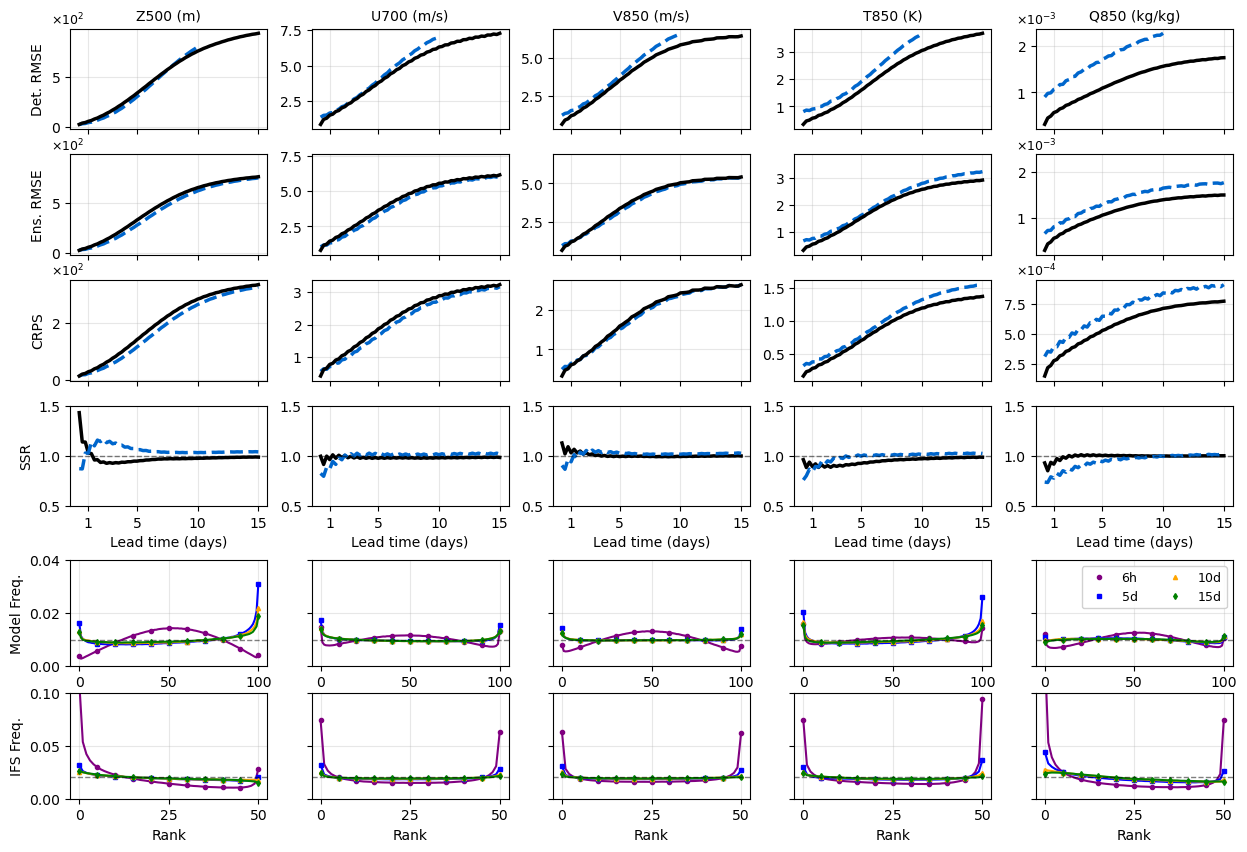

In [35]:
plot_ensemble_metrics(
    filename,
    ['Z500', 'U700', 'V850','T850', 'Q850'], # ['Z500', 'U500', 'V700','T500', 'Q700']
    ifs_file=ifs_filename,
    deterministic_file=deterministic_file, 
    ifs_deterministic_file=ifs_deterministic_file
)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.gridspec import GridSpec

def plot_rmse_comparison(csv_file, variables_to_plot, output_file='rmse_comparison.png', 
                         ifs_file=None, deterministic_file=None, ifs_deterministic_file=None):
    """
    Two-panel plot comparing deterministic and ensemble RMSE between model and IFS.
    
    Args:
        csv_file: Model ensemble metrics CSV
        variables_to_plot: List of variable names to plot
        output_file: Output filename
        ifs_file: IFS ensemble metrics CSV
        deterministic_file: Model deterministic metrics CSV
        ifs_deterministic_file: IFS deterministic (HRES) metrics CSV
    """
    def parse_var_level(var_name):
        import re
        name = var_name.lower()
        if 't2m' in name:
            return 't2m', None
        if 'mean_sea_level_pressure' in name or 'mslp' in name:
            return 'mslp', None
        m = re.search(r'(\d+)', var_name)
        level = float(m.group(1)) if m else None
        base_match = re.match(r'^([A-Za-z]+)', var_name)
        base = base_match.group(1).upper() if base_match else var_name.split('_')[0].upper()
        return base, level

    def get_units(var_name):
        """Get appropriate units for variable name"""
        var_base, level = parse_var_level(var_name)
        
        unit_map = {
            'Z': 'm',
            'U': 'm/s',
            'V': 'm/s',
            'T': 'K',
            'Q': 'kg/kg',
            't2m': 'K',
            'mslp': 'Pa'
        }
        
        return unit_map.get(var_base, '')

    var_map = {
        't2m': '2m_temperature',
        'mslp': 'mean_sea_level_pressure',
        'T': 'temperature',
        'Q': 'specific_humidity',
        'U': 'u_component_of_wind',
        'V': 'v_component_of_wind',
        'Z': 'geopotential'
    }

    # Load model ensemble data
    df = pd.read_csv(csv_file)
    lead_times = np.sort(df['lead_time'].unique())
    lead_times_days = lead_times / 24

    # Load IFS ensemble data
    if ifs_file is not None:
        ifs_df = pd.read_csv(ifs_file)
    else:
        ifs_df = None

    # Load deterministic data
    if deterministic_file is not None:
        det_df = pd.read_csv(deterministic_file)
    else:
        det_df = None

    if ifs_deterministic_file is not None:
        ifs_det_df = pd.read_csv(ifs_deterministic_file)
    else:
        ifs_det_df = None

    n_vars = len(variables_to_plot)
    
    # Layout: 2 rows × n_vars columns
    fig = plt.figure(figsize=(15, 5))
    gs = GridSpec(2, n_vars, hspace=0.15, wspace=0.3, figure=fig)

    color_pred = '#000000'
    color_ifs = '#0066CC'

    for col, var_name in enumerate(variables_to_plot):
        all_vars = df['variable'].unique()
        
        # Find matching variable in model ensemble data
        actual_var = next((v for v in all_vars if var_name.lower() in v.lower()), None)
        
        if actual_var is None:
            var_base, level = parse_var_level(var_name)
            if level is not None:
                candidate = f"{var_base}_PRES_{int(level)}mb"
                if candidate in all_vars:
                    actual_var = candidate
                elif candidate.lower() in [v.lower() for v in all_vars]:
                    actual_var = next(v for v in all_vars if v.lower() == candidate.lower())

        if actual_var is None:
            print(f"Warning: {var_name} not found in file — skipping.")
            continue

        var_data = df[df['variable'] == actual_var].sort_values('lead_time')

        # Match IFS ensemble data
        has_ifs = False
        aligned_ifs = {}
        if ifs_df is not None:
            var_base, level = parse_var_level(var_name)
            ifs_var = var_map.get(var_base)
            if ifs_var:
                if level is None:
                    ifs_match = ifs_df[ifs_df['variable'] == ifs_var].sort_values('lead_time_hours')
                else:
                    ifs_match = ifs_df[
                        (ifs_df['variable'] == ifs_var) & 
                        (ifs_df['level'] == level)
                    ].sort_values('lead_time_hours')
                    
                    if ifs_match.empty:
                        ifs_match = ifs_df[
                            (ifs_df['variable'] == ifs_var) & 
                            (np.abs(ifs_df['level'] - level) < 1.0)
                        ].sort_values('lead_time_hours')
                
                if not ifs_match.empty:
                    aligned_ifs = {
                        k: np.interp(lead_times, ifs_match['lead_time_hours'], ifs_match[k])
                        for k in ['rmse'] if k in ifs_match.columns
                    }
                    has_ifs = True

        # Match deterministic data
        det_data = None
        ifs_det_data = None
        
        if det_df is not None:
            det_data = det_df[det_df['variable'] == actual_var].sort_values('lead_time')
            det_data = det_data.dropna(subset=['rmse'])

        if ifs_det_df is not None:
            var_base, level = parse_var_level(var_name)
            ifs_var = var_map.get(var_base)
            if ifs_var:
                if level is None:
                    ifs_det_data = ifs_det_df[ifs_det_df['variable'] == ifs_var].sort_values('lead_time_hours')
                else:
                    ifs_det_data = ifs_det_df[
                        (ifs_det_df['variable'] == ifs_var) & 
                        (ifs_det_df['level'] == level)
                    ].sort_values('lead_time_hours')
                    
                    if ifs_det_data.empty:
                        ifs_det_data = ifs_det_df[
                            (ifs_det_df['variable'] == ifs_var) & 
                            (np.abs(ifs_det_df['level'] - level) < 1.0)
                        ].sort_values('lead_time_hours')
                
                if not ifs_det_data.empty:
                    ifs_det_data = ifs_det_data.dropna(subset=['rmse'])

        # Get units for title
        units = get_units(var_name)
        title_str = f"{var_name} ({units})" if units else var_name

        # --- DETERMINISTIC RMSE (Row 1) ---
        ax_det = fig.add_subplot(gs[0, col])
        
        if ifs_det_data is not None and len(ifs_det_data) > 0:
            lead_days = ifs_det_data['lead_time_hours'].values / 24
            ax_det.plot(lead_days, ifs_det_data['rmse'], color=color_ifs, ls='--', lw=2.5, label='IFS')
        
        if det_data is not None and len(det_data) > 0:
            lead_days = det_data['lead_time'].values / 24
            ax_det.plot(lead_days, det_data['rmse'], color=color_pred, ls='-', lw=2.5, label='Model')

        ax_det.set_title(title_str, fontsize=11)
        ax_det.grid(True, alpha=0.3)
        ax_det.set_xticks([1, 5, 10, 15])
        ax_det.set_xticklabels(["", "", "", ""])
        
        if col == 0:
            ax_det.set_ylabel('Det. RMSE', fontsize=11)
        
        ax_det.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax_det.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax_det.yaxis.get_offset_text().set_fontsize(8)

        # --- ENSEMBLE RMSE (Row 2) ---
        ax_ens = fig.add_subplot(gs[1, col], sharex=ax_det, sharey=ax_det)
        
        # Plot IFS ensemble RMSE
        if has_ifs and 'rmse' in aligned_ifs:
            ax_ens.plot(lead_times_days, aligned_ifs['rmse'], color=color_ifs, ls='--', lw=2.5, label='IFS')
        
        # Plot model ensemble RMSE
        ax_ens.plot(lead_times_days, var_data['rmse'], color=color_pred, ls='-', lw=2.5, label='Model')
        
        ax_ens.grid(True, alpha=0.3)
        ax_ens.set_xticks([1, 5, 10, 15])
        ax_ens.set_xlabel('Lead time (days)', fontsize=11)
        
        if col == 0:
            ax_ens.set_ylabel('Ens. RMSE', fontsize=11)
        
        ax_ens.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax_ens.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax_ens.yaxis.get_offset_text().set_fontsize(8)

    plt.tight_layout()
    # plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()

/glade/derecho/scratch/schreck/tmp/ipykernel_60143/486546706.py:216: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


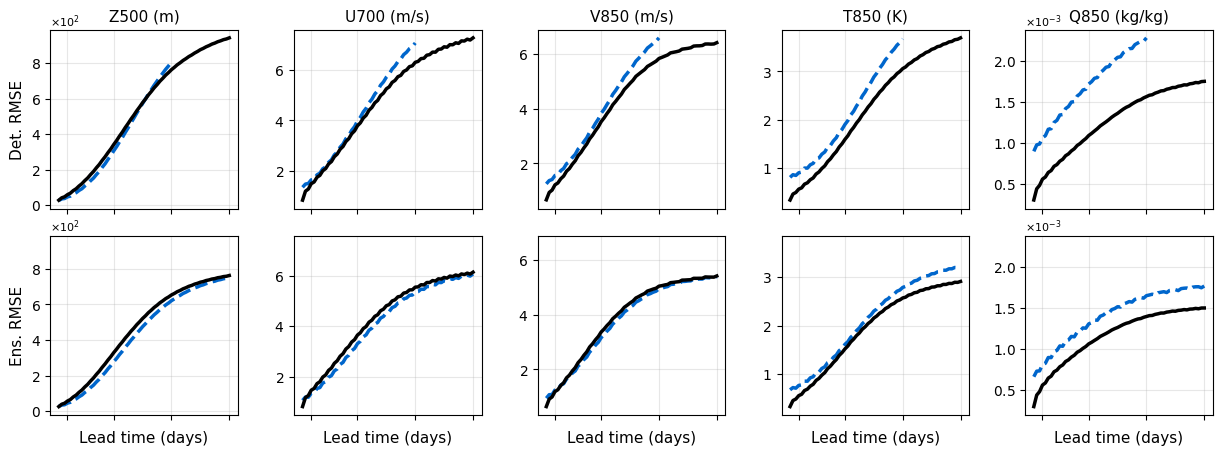

In [24]:
plot_rmse_comparison(
    filename,
    ['Z500', 'U700', 'V850','T850', 'Q850'], # ['Z500', 'U500', 'V700','T500', 'Q700']
    ifs_file=ifs_filename,
    deterministic_file=deterministic_file, 
    ifs_deterministic_file=ifs_deterministic_file
)